In [1]:
import json
import os
import pandas as pd

folder_path = r"C:\Users\dell\Desktop\Projects using DS\ipl_json"

matches_list = []

for file in os.listdir(folder_path):
    if file.endswith(".json"):
        with open(os.path.join(folder_path, file), 'r') as f:
            data = json.load(f)
            
            info = data['info']
            
            match = {
                'match_id': file.replace('.json', ''),
                'date': info['dates'][0],
                'venue': info['venue'],
                'city': info.get('city', 'Unknown'),
                'team1': info['teams'][0],
                'team2': info['teams'][1],
                'toss_winner': info['toss']['winner'],
                'toss_decision': info['toss']['decision'],
                'winner': info.get('outcome', {}).get('winner', 'No Result'),
                'win_by_runs': info.get('outcome', {}).get('by', {}).get('runs', 0),
                'win_by_wickets': info.get('outcome', {}).get('by', {}).get('wickets', 0),
                'player_of_match': info.get('player_of_match', ['Unknown'])[0],
            }
            matches_list.append(match)

# DataFrame banao
df = pd.DataFrame(matches_list)

# CSV save karo
df.to_csv(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\ipl_matches.csv", index=False)

print(f"Total matches: {len(df)}")
df.head()

Total matches: 1243


,match_id,date,venue,city,team1,team2,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match
0,1082591,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35,0,Yuvraj Singh
1,1082592,2017-04-06,Maharashtra Cricket Association Stadium,Pune,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiant,0,7,SPD Smith
2,1082593,2017-04-07,Saurashtra Cricket Association Stadium,Rajkot,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,0,10,CA Lynn
3,1082594,2017-04-08,Holkar Cricket Stadium,Indore,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,field,Kings XI Punjab,0,6,GJ Maxwell
4,1082595,2017-04-08,M.Chinnaswamy Stadium,Bengaluru,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,15,0,KM Jadhav


In [2]:
df.shape

(1243, 12)

In [3]:
# Date column ko datetime mein convert karo
df['date'] = pd.to_datetime(df['date'])

# Season (year) nikalo
df['season'] = df['date'].dt.year

# Kitne matches har season mein hain
print(df['season'].value_counts().sort_index())
print(f"\nTotal matches: {len(df)}")
print(f"Seasons covered: {df['season'].min()} to {df['season'].max()}")

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
2025    74
2026    74
Name: count, dtype: int64

Total matches: 1243
Seasons covered: 2008 to 2026


In [4]:
df.isnull().sum()

match_id           0
date               0
venue              0
city               0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
season             0
dtype: int64

In [5]:
df['winner'].unique()

array(['Sunrisers Hyderabad', 'Rising Pune Supergiant',
       'Kolkata Knight Riders', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Mumbai Indians',
       'Delhi Daredevils', 'Gujarat Lions', 'No Result',
       'Chennai Super Kings', 'Rajasthan Royals', 'Delhi Capitals',
       'Punjab Kings', 'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru', 'Deccan Chargers', 'Pune Warriors',
       'Kochi Tuskers Kerala', 'Rising Pune Supergiants'], dtype=object)

In [6]:
df['winner'] = df['winner'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

In [7]:
df['winner'].unique()

array(['Sunrisers Hyderabad', 'Rising Pune Supergiants',
       'Kolkata Knight Riders', 'Punjab Kings',
       'Royal Challengers Bengaluru', 'Mumbai Indians', 'Delhi Capitals',
       'Gujarat Lions', 'No Result', 'Chennai Super Kings',
       'Rajasthan Royals', 'Gujarat Titans', 'Lucknow Super Giants',
       'Deccan Chargers', 'Pune Warriors', 'Kochi Tuskers Kerala'],
      dtype=object)

In [8]:
df[df['winner']=='No Result'].count()

match_id           25
date               25
venue              25
city               25
team1              25
team2              25
toss_winner        25
toss_decision      25
winner             25
win_by_runs        25
win_by_wickets     25
player_of_match    25
season             25
dtype: int64

In [9]:
df = df[df['winner'] != 'No Result']
df.shape

(1218, 13)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.to_csv(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\ipl_matches_clean.csv", index=False)
print("Saved!")

Saved!


<Axes: xlabel='winner'>

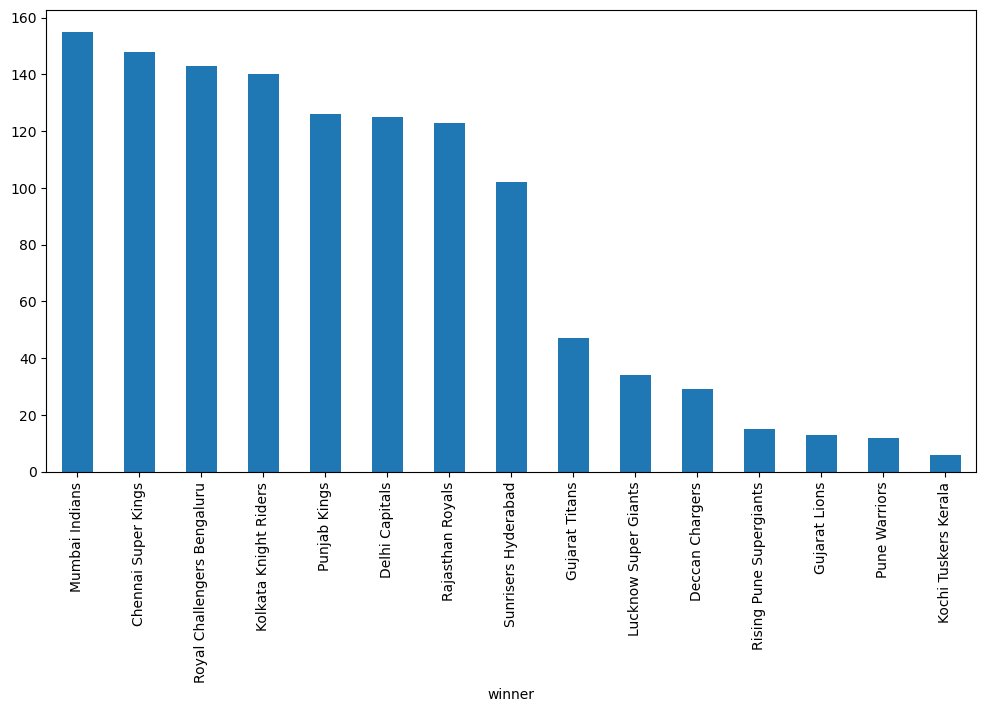

In [12]:
df['winner'].value_counts().plot(kind ='bar', figsize=(12,6))

C:\Users\dell\AppData\Local\Temp\ipykernel_9364\977077793.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values, y=top_teams.index, palette='viridis')


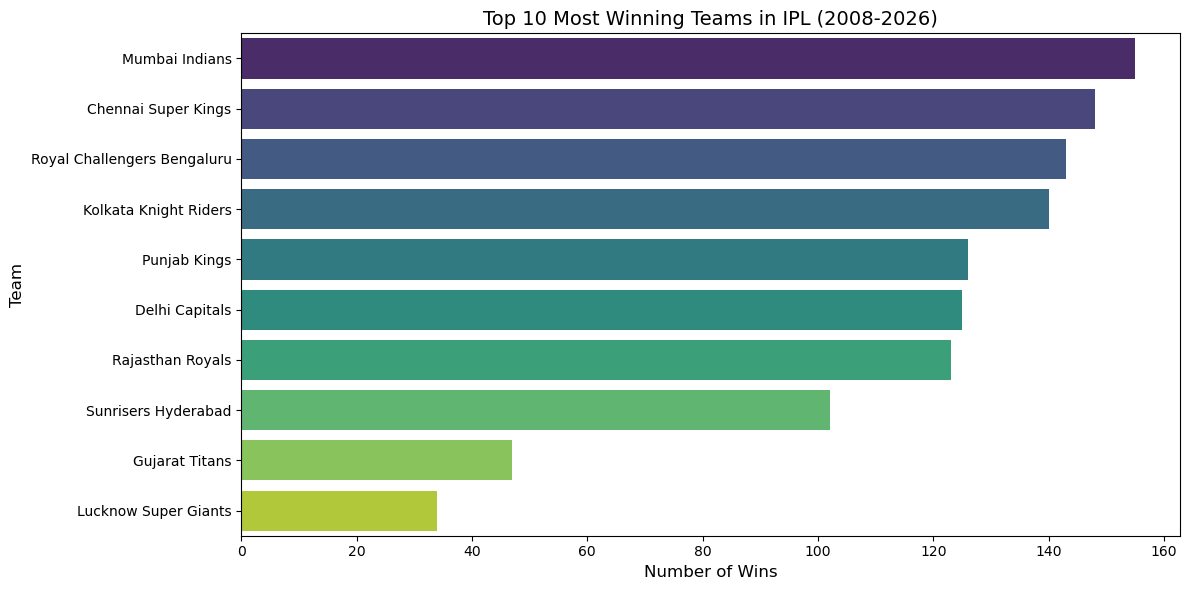

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

top_teams = df['winner'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_teams.values, y=top_teams.index, palette='viridis')
plt.title('Top 10 Most Winning Teams in IPL (2008-2026)', fontsize=14)
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\top_teams.png")
plt.show()

In [14]:
df['toss_match_winner'] = df['toss_winner'] == df['winner']
df.head()

,match_id,date,venue,city,team1,team2,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match,season,toss_match_winner
0,1082591,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35,0,Yuvraj Singh,2017,False
1,1082592,2017-04-06,Maharashtra Cricket Association Stadium,Pune,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiants,0,7,SPD Smith,2017,False
2,1082593,2017-04-07,Saurashtra Cricket Association Stadium,Rajkot,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,0,10,CA Lynn,2017,True
3,1082594,2017-04-08,Holkar Cricket Stadium,Indore,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,field,Punjab Kings,0,6,GJ Maxwell,2017,False
4,1082595,2017-04-08,M.Chinnaswamy Stadium,Bengaluru,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,Royal Challengers Bengaluru,15,0,KM Jadhav,2017,False


In [15]:
df['toss_match_winner'].mean() * 100

np.float64(40.804597701149426)

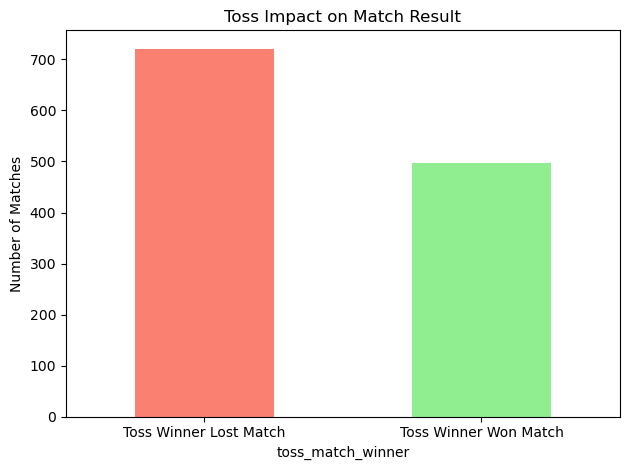

In [16]:
toss_impact = df['toss_match_winner'].value_counts()
labels = ['Toss Winner Lost Match', 'Toss Winner Won Match']

toss_impact.plot(kind='bar', color=['salmon', 'lightgreen'])
plt.title('Toss Impact on Match Result')
plt.xticks([0, 1], labels, rotation=0)
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

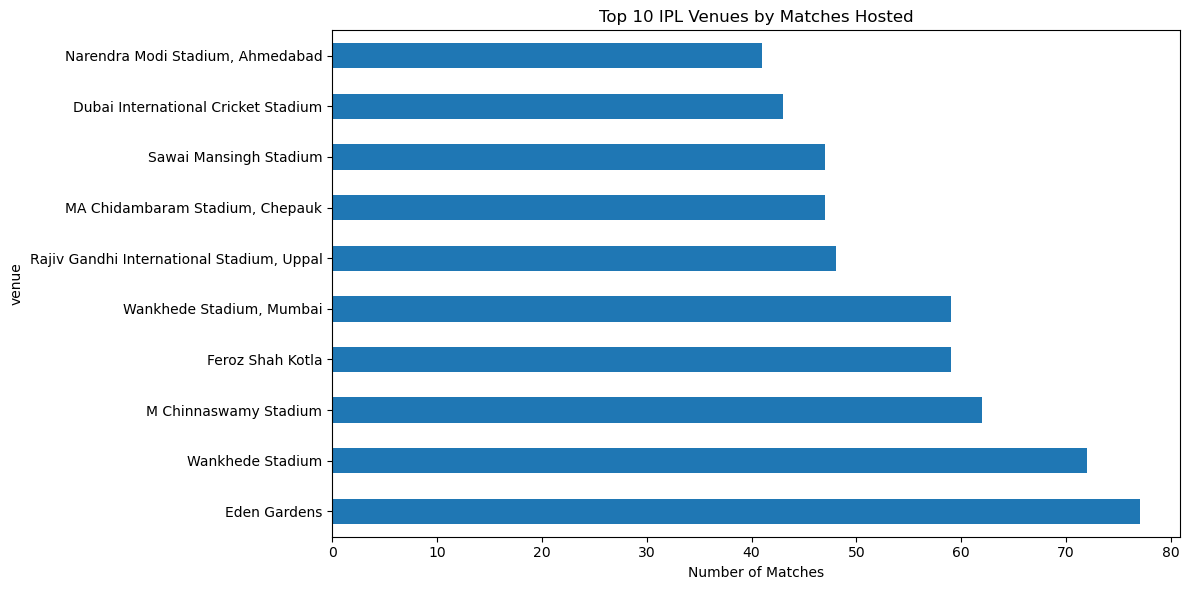

In [17]:
top_venues = df['venue'].value_counts().head(10)
top_venues.plot(kind='barh', figsize=(12, 6))
plt.title('Top 10 IPL Venues by Matches Hosted')
plt.xlabel('Number of Matches')
plt.tight_layout()
plt.show()

In [18]:
# 1. Kya toss winner ne match jeeta?
df['toss_won_match'] = (df['toss_winner'] == df['winner']).astype(int)

# 2. Batting ya fielding — toss decision encode karo
df['bat_first'] = (df['toss_decision'] == 'bat').astype(int)

# 3. Team1 aur Team2 ke liye Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['team1_encoded'] = le.fit_transform(df['team1'])
df['team2_encoded'] = le.fit_transform(df['team2'])
df['venue_encoded'] = le.fit_transform(df['venue'])
df['toss_winner_encoded'] = le.fit_transform(df['toss_winner'])
df['winner_encoded'] = le.fit_transform(df['winner'])

print(df.head())
print(df.shape)

  match_id       date                                      venue       city  \
0  1082591 2017-04-05  Rajiv Gandhi International Stadium, Uppal  Hyderabad   
1  1082592 2017-04-06    Maharashtra Cricket Association Stadium       Pune   
2  1082593 2017-04-07     Saurashtra Cricket Association Stadium     Rajkot   
3  1082594 2017-04-08                     Holkar Cricket Stadium     Indore   
4  1082595 2017-04-08                      M.Chinnaswamy Stadium  Bengaluru   

                         team1                        team2  \
0          Sunrisers Hyderabad  Royal Challengers Bangalore   
1       Rising Pune Supergiant               Mumbai Indians   
2                Gujarat Lions        Kolkata Knight Riders   
3              Kings XI Punjab       Rising Pune Supergiant   
4  Royal Challengers Bangalore             Delhi Daredevils   

                   toss_winner toss_decision                       winner  \
0  Royal Challengers Bangalore         field          Sunrisers Hyder

In [19]:
df.to_csv(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\ipl_final.csv", index=False)
print("Saved!")

Saved!


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Lets define target or features
X = df[['team1_encoded', 'team2_encoded', 'venue_encoded', 
        'toss_winner_encoded', 'bat_first', 'season']]
Y = df['winner_encoded']

#train and test split
X_train , X_test , Y_train,Y_test = train_test_split(X,Y,
                                                    test_size=0.2,
                                                    random_state=42)
model = RandomForestClassifier(n_estimators=100 , random_state=42)
model.fit(X_train,Y_train)

#Check accuracy
Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 49.18%


In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Better model try karo
model2 = GradientBoostingClassifier(n_estimators=200, random_state=42)
model2.fit(X_train, Y_train)

Y_pred2 = model2.predict(X_test)
accuracy2 = accuracy_score(Y_test,Y_pred2)
print(f"GradientBoosting Accuracy: {accuracy2 * 100:.2f}%")

GradientBoosting Accuracy: 50.00%


In [22]:
# Team apne city mein khel rahi hai?
df['team1_home'] = (df['city'] == df['team1'].map({
    'Mumbai Indians': 'Mumbai',
    'Chennai Super Kings': 'Chennai',
    'Royal Challengers Bengaluru': 'Bengaluru',
    'Kolkata Knight Riders': 'Kolkata',
    'Delhi Capitals': 'Delhi',
    'Sunrisers Hyderabad': 'Hyderabad',
    'Rajasthan Royals': 'Jaipur',
    'Punjab Kings': 'Chandigarh',
    'Gujarat Titans': 'Ahmedabad',
    'Lucknow Super Giants': 'Lucknow'
})).astype(int)

print(df['team1_home'].value_counts())


team1_home
0    832
1    386
Name: count, dtype: int64


In [23]:
df['team2_home'] = (df['city'] == df['team2'].map({
    'Mumbai Indians': 'Mumbai',
    'Chennai Super Kings': 'Chennai',
    'Royal Challengers Bengaluru': 'Bengaluru',
    'Kolkata Knight Riders': 'Kolkata',
    'Delhi Capitals': 'Delhi',
    'Sunrisers Hyderabad': 'Hyderabad',
    'Rajasthan Royals': 'Jaipur',
    'Punjab Kings': 'Chandigarh',
    'Gujarat Titans': 'Ahmedabad',
    'Lucknow Super Giants': 'Lucknow'
})).astype(int)

In [24]:
# Updated features
X = df[['team1_encoded', 'team2_encoded', 'venue_encoded', 
        'toss_winner_encoded', 'bat_first', 'season',
        'team1_home', 'team2_home']]
Y = df['winner_encoded']

# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Model train karo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

# Accuracy check karo
Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 45.08%


In [25]:
X = df[['team1_encoded', 'team2_encoded', 'venue_encoded', 
        'toss_winner_encoded', 'bat_first', 'season']]
Y = df['winner_encoded']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 49.18%


In [26]:
import pickle

# Model save karna
with open(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\ipl_model.pkl", 'wb') as f:
    pickle.dump(model, f)

# LabelEncoder bhi save karna
with open(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\label_encoder.pkl", 'wb') as f:
    pickle.dump(le, f)

print("Model saved!")

Model saved!


In [27]:
print(le.classes_)

['Chennai Super Kings' 'Deccan Chargers' 'Delhi Capitals' 'Gujarat Lions'
 'Gujarat Titans' 'Kochi Tuskers Kerala' 'Kolkata Knight Riders'
 'Lucknow Super Giants' 'Mumbai Indians' 'Pune Warriors' 'Punjab Kings'
 'Rajasthan Royals' 'Rising Pune Supergiants'
 'Royal Challengers Bengaluru' 'Sunrisers Hyderabad']


In [28]:
print(df.columns.tolist())

['match_id', 'date', 'venue', 'city', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'season', 'toss_match_winner', 'toss_won_match', 'bat_first', 'team1_encoded', 'team2_encoded', 'venue_encoded', 'toss_winner_encoded', 'winner_encoded', 'team1_home', 'team2_home']


In [29]:
from sklearn.preprocessing import LabelEncoder

venue_le = LabelEncoder()
venue_le.fit(df['venue'])

print(len(venue_le.classes_))
print(venue_le.classes_[:10])

60
['Arun Jaitley Stadium' 'Arun Jaitley Stadium, Delhi' 'Barabati Stadium'
 'Barsapara Cricket Stadium, Guwahati'
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow'
 'Brabourne Stadium' 'Brabourne Stadium, Mumbai' 'Buffalo Park'
 'De Beers Diamond Oval' 'Dr DY Patil Sports Academy']


In [30]:
print(df[['venue', 'venue_encoded']].head())

                                       venue  venue_encoded
0  Rajiv Gandhi International Stadium, Uppal             43
1    Maharashtra Cricket Association Stadium             31
2     Saurashtra Cricket Association Stadium             46
3                     Holkar Cricket Stadium             20
4                      M.Chinnaswamy Stadium             25


In [32]:
df[df['venue'].str.contains('Wankhede')]['venue'].unique()

array(['Wankhede Stadium', 'Wankhede Stadium, Mumbai'], dtype=object)

In [34]:
print(repr(le.classes_))

array(['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals',
       'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala',
       'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians',
       'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals',
       'Rising Pune Supergiants', 'Royal Challengers Bengaluru',
       'Sunrisers Hyderabad'], dtype=object)


In [36]:
from sklearn.preprocessing import LabelEncoder

# Alag encoders banao
le_team = LabelEncoder()
le_venue = LabelEncoder()

# Saari teams ek saath fit karo (team1 + team2 + toss_winner + winner sab same teams hain)
all_teams = pd.concat([df['team1'], df['team2'], df['toss_winner'], df['winner']]).unique()
le_team.fit(all_teams)

# Encode karo
df['team1_encoded'] = le_team.transform(df['team1'])
df['team2_encoded'] = le_team.transform(df['team2'])
df['toss_winner_encoded'] = le_team.transform(df['toss_winner'])
df['winner_encoded'] = le_team.transform(df['winner'])

# Venue alag se
df['venue_encoded'] = le_venue.fit_transform(df['venue'])

print("Teams:", le_team.classes_)
print("\nVenues:", le_venue.classes_)

Teams: ['Chennai Super Kings' 'Deccan Chargers' 'Delhi Capitals'
 'Delhi Daredevils' 'Gujarat Lions' 'Gujarat Titans' 'Kings XI Punjab'
 'Kochi Tuskers Kerala' 'Kolkata Knight Riders' 'Lucknow Super Giants'
 'Mumbai Indians' 'Pune Warriors' 'Punjab Kings' 'Rajasthan Royals'
 'Rising Pune Supergiant' 'Rising Pune Supergiants'
 'Royal Challengers Bangalore' 'Royal Challengers Bengaluru'
 'Sunrisers Hyderabad']

Venues: ['Arun Jaitley Stadium' 'Arun Jaitley Stadium, Delhi' 'Barabati Stadium'
 'Barsapara Cricket Stadium, Guwahati'
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow'
 'Brabourne Stadium' 'Brabourne Stadium, Mumbai' 'Buffalo Park'
 'De Beers Diamond Oval' 'Dr DY Patil Sports Academy'
 'Dr DY Patil Sports Academy, Mumbai'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam'
 'Dubai International Cricket Stadium' 'Eden Gardens'
 'Eden Gardens, Kolkata' 'Feroz Shah Kotla' 'Green Park'
 '

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[['team1_encoded', 'team2_encoded', 'venue_encoded', 
        'toss_winner_encoded', 'bat_first', 'season']]
Y = df['winner_encoded']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 49.18%


In [39]:
import pickle

# Model save karo
with open(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\ipl_model.pkl", 'wb') as f:
    pickle.dump(model, f)

# Team encoder save karo
with open(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\team_encoder.pkl", 'wb') as f:
    pickle.dump(le_team, f)

# Venue encoder save karo
with open(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\venue_encoder.pkl", 'wb') as f:
    pickle.dump(le_venue, f)

print("All saved!")

All saved!
